# Biome estimation exercise

Below you will 

In [1]:
#%pip install cartopy


In [2]:
#%pip install ISLP

In [3]:
#%pip install shap

In [4]:
import pandas as pd
import cartopy.crs as ccrs # Enables geographic mapping, e.g., drawing coastlines, etc
import matplotlib.pyplot as plt


proj = ccrs.PlateCarree()

In [5]:
def format_rbg_string(rgbstring):
    """Transform a RGB string to a tuple of floats that matplotlib can understand"""
    rgbs = rgbstring.split(' ')
    rgbtup = tuple(float(rgb) for rgb in rgbs)
    return rgbtup

with open('legend of biomes.txt', 'r') as f:
    lines = [ l.strip() for l in f.readlines()] # Remove endline characters and spaces
    
biome_names = lines[slice(0, len(lines), 2)] # Only use the biome names, not the colors
biome_names = [ ' '.join(l.split(' ')[1:]) for l in biome_names ] # Remove number in front of names
biome_rgbs = lines[slice(1, len(lines), 2)] # Filter out biome RGB colors
biome_rgbs = [format_rbg_string(rgbstr) for rgbstr in biome_rgbs]
biome_names

['Boreal decid forest',
 'Boreal ever forest',
 'Temp/boreal mix fo.',
 'Temp conifer forest',
 'Temp decid forest',
 'Temp broad ever fo.',
 'Temp mixed forest',
 'Trop season forest',
 'Trop rain forest',
 'Trop decid forest',
 'Moist savannas',
 'Dry savannas',
 'Tall grassland',
 'Dry grassland',
 'Xeric wood/shrub',
 'Arid shrub/steppe',
 'Desert',
 'Arctic/alpine tundra']

In [6]:
countries = pd.read_csv('gridlist_pan_gfed_ISO3_UN_ecoregion.txt', sep='\\s+')
countries.head()

,Lon,Lat,GFED-region,Pan_2007,ISO3,UN,Ecoregion
0,-69.75,-55.25,5,Americas,CHL,152,4
1,-69.25,-55.25,5,Americas,CHL,152,4
2,-71.25,-54.75,5,Americas,CHL,152,4
3,-70.75,-54.75,5,Americas,CHL,152,4
4,-70.25,-54.75,5,Americas,CHL,152,4


In [7]:
# Biome obs from Haxeltine & Prentice, 1996
df = pd.read_csv('data/LPJ-GUESS_output_BERN1.csv')
df.head()

,Lon,Lat,NPP,SoilR,MaxBiomeCmax,MaxBiomeLAI,VegC,LitterC,SoilC,Biome_Cmax,Biome_LAI,Biome_obs
0,39.75,-1.25,0.429,0.390,0.449,1.9821,1.225,0.758,5.941,8,12,12
1,150.25,-34.25,0.554,0.451,6.883,3.3174,6.953,3.221,10.566,7,7,6
2,-63.75,82.75,0.000,0.000,0.000,0.0000,0.000,0.003,0.002,13,13,17
3,59.25,30.75,0.043,0.042,0.090,0.2146,0.127,0.084,0.543,7,11,14
4,24.25,27.75,0.000,0.000,0.000,0.0000,0.000,0.000,0.000,13,13,17


In [8]:
biome_data = df[['Lon', 'Lat', 'Biome_obs']]
biome_data['Biome_obs'].value_counts()

Biome_obs
2     11118
17     6505
9      5924
18     5725
16     4577
14     3965
5      3962
12     3643
15     3134
6      2748
8      2560
10     1702
1      1383
11     1027
3       734
13      367
7       117
Name: count, dtype: int64

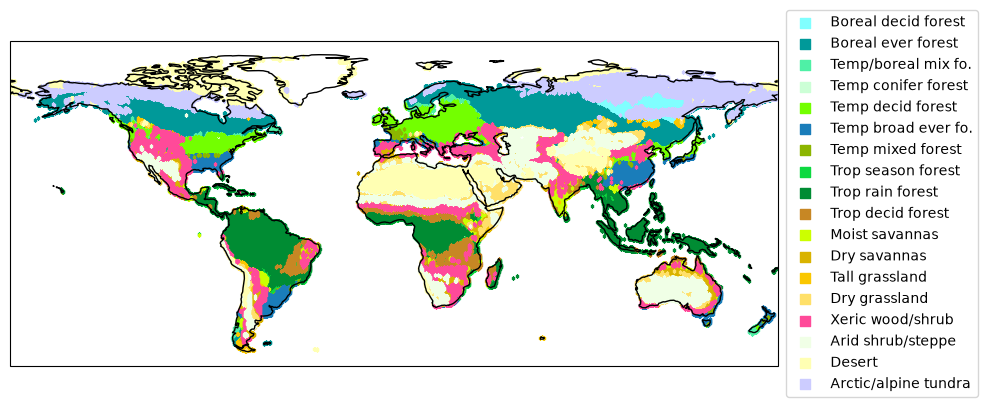

In [9]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=proj))

# Hacky way of creating a map, pretent it is a scatterplot with lons and lats on x and y!
for i, name in enumerate(biome_names):
    biome = biome_data[biome_data['Biome_obs'] == i +1]
    biome.plot(x='Lon', y='Lat', color=biome_rgbs[i], ax=ax, kind='scatter', s=.6, label=name, marker='s')


ax.legend(markerscale=10, loc='center right', bbox_to_anchor=(1.27, .5)) # Make markers bigger
ax.coastlines()
plt.tight_layout()
plt.show()

# Start your data formatting below. Good luck!

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

Data Visualization

Variables' distribution in EU 

In [11]:
df_pre   = pd.read_csv('data/Predaymean1961_1990_stats.csv')
df_tmp   = pd.read_csv('data/Tmpdaymean1961_1990_stats.csv')
df_tmax  = pd.read_csv('data/Tmaxdaymean1961_1990_stats.csv')
df_tmin  = pd.read_csv('data/Tmindaymean1961_1990_stats.csv')
df_tswrf = pd.read_csv('data/Tswrfdaymean1961_1990_stats.csv')

def prepare_df(df, prefix):

    df = df.rename(columns={'lon': 'Lon', 'lat': 'Lat', 'longitude': 'Lon', 'latitude': 'Lat'})
    rename_dict = {col: f"{prefix}_{col}" for col in df.columns if col not in ['Lon', 'Lat']}
    return df.rename(columns=rename_dict)

df_pre   = prepare_df(df_pre, 'pre')
df_tmp   = prepare_df(df_tmp, 'tmp')
df_tmax  = prepare_df(df_tmax, 'tmax')
df_tmin  = prepare_df(df_tmin, 'tmin')
df_tswrf = prepare_df(df_tswrf, 'tswrf')

climate_dfs = [df_pre, df_tmp, df_tmax, df_tmin, df_tswrf]
df_climate = climate_dfs[0]
for df in climate_dfs[1:]:
    df_climate = pd.merge(df_climate, df, on=['Lon', 'Lat'], how='inner')

df_target = pd.read_csv('data/LPJ-GUESS_output_BERN1.csv')
gridlist  = pd.read_csv('gridlist_pan_gfed_ISO3_UN_ecoregion.txt', sep=r'\s+')

for df in [df_target, gridlist]:
    df.rename(columns={'lon': 'Lon', 'lat': 'Lat', 'longitude': 'Lon', 'latitude': 'Lat'}, inplace=True)

df_merged = pd.merge(df_climate, df_target, on=['Lon', 'Lat'], how='inner')
df_merged = pd.merge(df_merged, gridlist, on=['Lon', 'Lat'], how='inner')

to_delete= ['pre_SpringMedian', 'pre_SpringStd','pre_SummerMedian', 'pre_SummerStd', 'pre_FallMedian', 'pre_FallStd', 'pre_WinterMedian', 'pre_WinterStd','tmp_SpringMedian', 'tmp_SpringStd','tmp_SummerMedian', 'tmp_SummerStd', 'tmp_FallMedian', 'tmp_FallStd','Pan_2007','tmp_WinterMedian', 'tmp_WinterStd', 'tmax_SpringMedian', 'tmax_SpringStd', 'tmax_SummerMedian', 'tmax_SummerStd', 'tmax_FallMedian', 'tmax_FallStd', 'tmax_WinterMedian', 'tmax_WinterStd', 'tmin_SpringMedian', 'tmin_SpringStd', 'tmin_SummerMedian', 'tmin_SummerStd', 'tmin_FallMedian', 'tmin_FallStd', 'tmin_WinterMedian', 'tmin_WinterStd', 'tswrf_SpringMedian', 'tswrf_SpringStd', 'tswrf_SummerMedian', 'tswrf_SummerStd', 'tswrf_FallMedian', 'tswrf_FallStd', 'tswrf_WinterMedian', 'tswrf_WinterStd']
df_merged = df_merged.drop(columns=to_delete)

df_canada = df_merged[df_merged['ISO3'] == 'CAN']
df_australia = df_merged[df_merged['ISO3'] == 'AUS']

europe_iso = [
    'SWE', 'NOR', 'FIN', 'DNK', 'ISL', 'GBR', 'IRL', 'DEU', 'FRA', 'ESP', 
    'PRT', 'ITA', 'NLD', 'BEL', 'CHE', 'AUT', 'POL', 'CZE', 'SVK', 'HUN', 
    'ROU', 'BGR', 'GRC', 'EST', 'LVA', 'LTU', 'BLR', 'UKR', 'HRV', 'SRB'
]
df_europe = df_merged[df_merged['ISO3'].isin(europe_iso)]

south_america_iso = [
    'BRA', 'ARG', 'COL', 'PER', 'VEN', 'CHL', 
    'ECU', 'BOL', 'PRY', 'URY', 'GUY', 'SUR'
]
df_south_america = df_merged[df_merged['ISO3'].isin(south_america_iso)]

print(f"Europe grid count: {len(df_europe)}")
print(f"Canada grid count: {len(df_canada)}")
print(f"South America grid count: {len(df_south_america)}")
print(f"Australia grid count: {len(df_australia)}")

Europe grid count: 3151
Canada grid count: 6499
South America grid count: 6190
Australia grid count: 2826


In [12]:
df_europe.head()

,Lon,Lat,pre_SpringMean,pre_SummerMean,pre_FallMean,pre_WinterMean,tmp_SpringMean,tmp_SummerMean,tmp_FallMean,tmp_WinterMean,...,VegC,LitterC,SoilC,Biome_Cmax,Biome_LAI,Biome_obs,GFED-region,ISO3,UN,Ecoregion
12,24.25,51.75,0.98248,1.8373,2.0895,1.3034,270.75,285.99,289.39,276.10,...,7.701,9.439,16.046,5,5,5,11,BLR,112,4
33,25.75,50.75,0.98353,1.9468,2.1311,1.2233,270.59,286.20,289.55,275.97,...,9.077,6.723,15.222,5,5,5,11,UKR,804,4
45,10.25,62.25,1.04720,1.3020,2.3092,1.4383,264.44,276.09,280.66,268.64,...,6.446,18.294,28.623,2,2,2,6,NOR,578,11
50,28.25,64.25,1.11170,1.5451,2.4035,1.6442,262.43,279.57,285.03,269.05,...,9.638,18.268,31.691,2,2,2,6,FIN,246,6
73,19.75,68.75,1.11800,1.1252,1.9308,1.3779,261.56,274.35,280.43,266.17,...,0.142,0.803,14.560,11,11,18,6,NOR,578,11


In [13]:
print(df_europe.columns.tolist())

['Lon', 'Lat', 'pre_SpringMean', 'pre_SummerMean', 'pre_FallMean', 'pre_WinterMean', 'tmp_SpringMean', 'tmp_SummerMean', 'tmp_FallMean', 'tmp_WinterMean', 'tmax_SpringMean', 'tmax_SummerMean', 'tmax_FallMean', 'tmax_WinterMean', 'tmin_SpringMean', 'tmin_SummerMean', 'tmin_FallMean', 'tmin_WinterMean', 'tswrf_SpringMean', 'tswrf_SummerMean', 'tswrf_FallMean', 'tswrf_WinterMean', 'NPP', 'SoilR', 'MaxBiomeCmax', 'MaxBiomeLAI', 'VegC', 'LitterC', 'SoilC', 'Biome_Cmax', 'Biome_LAI', 'Biome_obs', 'GFED-region', 'ISO3', 'UN', 'Ecoregion']


In [14]:
print(df_south_america.columns.tolist())

['Lon', 'Lat', 'pre_SpringMean', 'pre_SummerMean', 'pre_FallMean', 'pre_WinterMean', 'tmp_SpringMean', 'tmp_SummerMean', 'tmp_FallMean', 'tmp_WinterMean', 'tmax_SpringMean', 'tmax_SummerMean', 'tmax_FallMean', 'tmax_WinterMean', 'tmin_SpringMean', 'tmin_SummerMean', 'tmin_FallMean', 'tmin_WinterMean', 'tswrf_SpringMean', 'tswrf_SummerMean', 'tswrf_FallMean', 'tswrf_WinterMean', 'NPP', 'SoilR', 'MaxBiomeCmax', 'MaxBiomeLAI', 'VegC', 'LitterC', 'SoilC', 'Biome_Cmax', 'Biome_LAI', 'Biome_obs', 'GFED-region', 'ISO3', 'UN', 'Ecoregion']


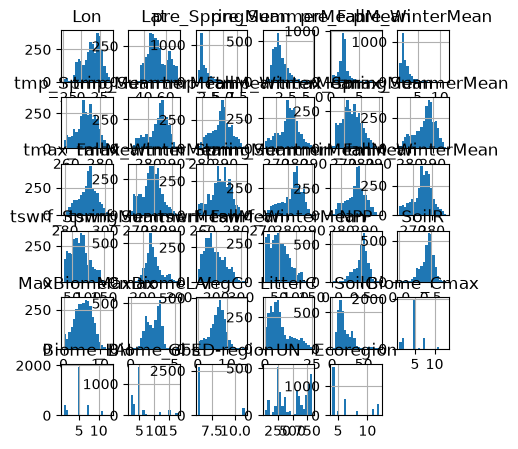

In [15]:
df_europe.hist(figsize=(5, 5), bins=20)
plt.show()

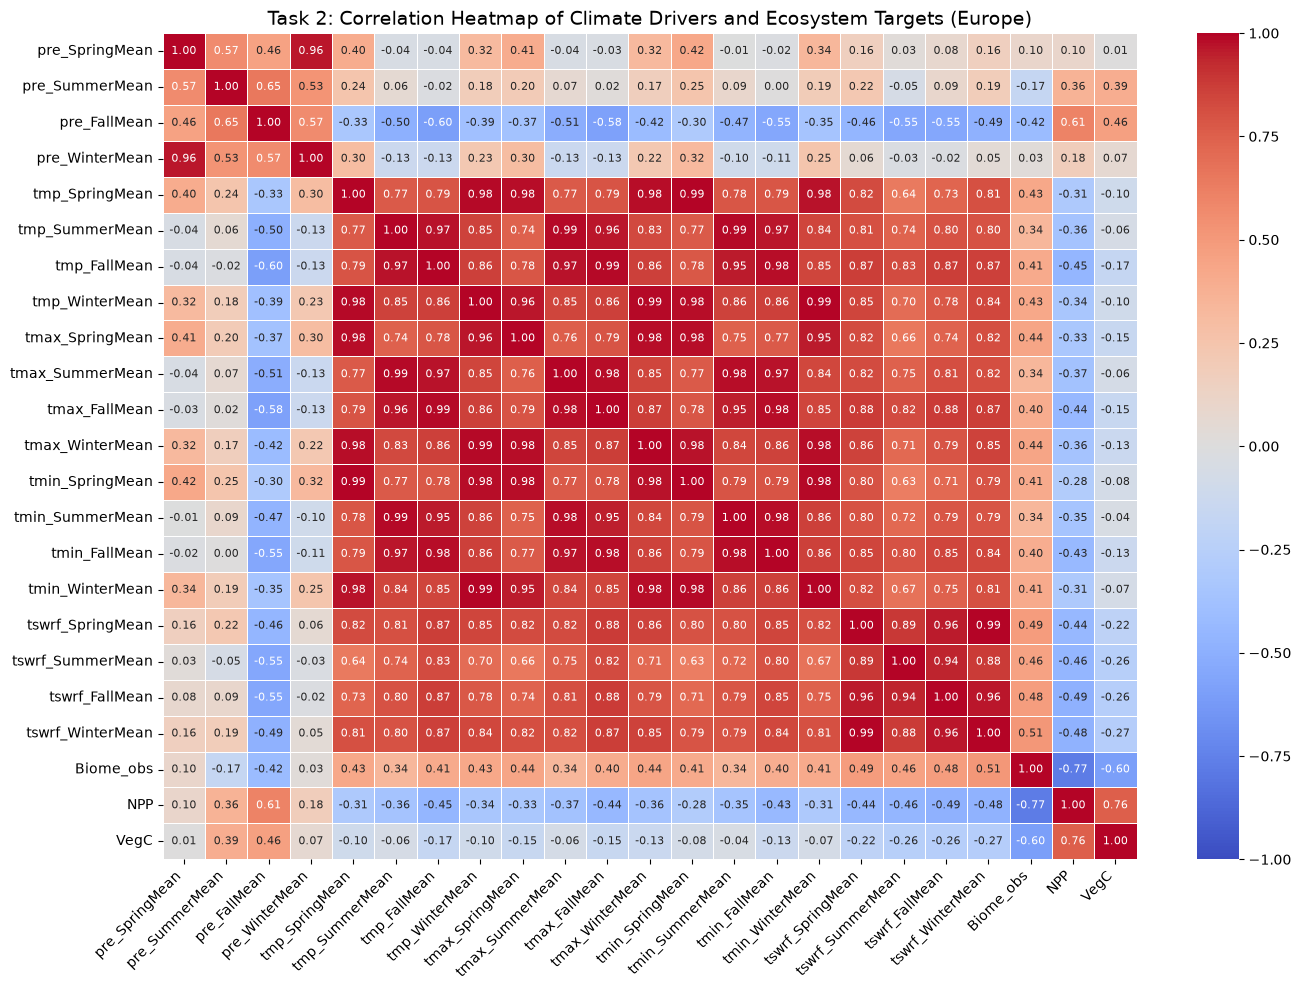

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
NUMERIC_FEATURES_AND_TARGETS = [

    'pre_SpringMean', 'pre_SummerMean', 'pre_FallMean', 'pre_WinterMean',

    'tmp_SpringMean', 'tmp_SummerMean', 'tmp_FallMean', 'tmp_WinterMean',

    'tmax_SpringMean', 'tmax_SummerMean', 'tmax_FallMean', 'tmax_WinterMean',

    'tmin_SpringMean', 'tmin_SummerMean', 'tmin_FallMean', 'tmin_WinterMean',

    'tswrf_SpringMean', 'tswrf_SummerMean', 'tswrf_FallMean', 'tswrf_WinterMean',
    
    'Biome_obs', 'NPP', 'VegC'
]


correlation_matrix = df_europe[NUMERIC_FEATURES_AND_TARGETS].corr()


plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5, 
    vmin=-1, vmax=1,
    annot_kws={"size": 8}
)

plt.title('Task 2: Correlation Heatmap of Climate Drivers and Ecosystem Targets (Europe)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

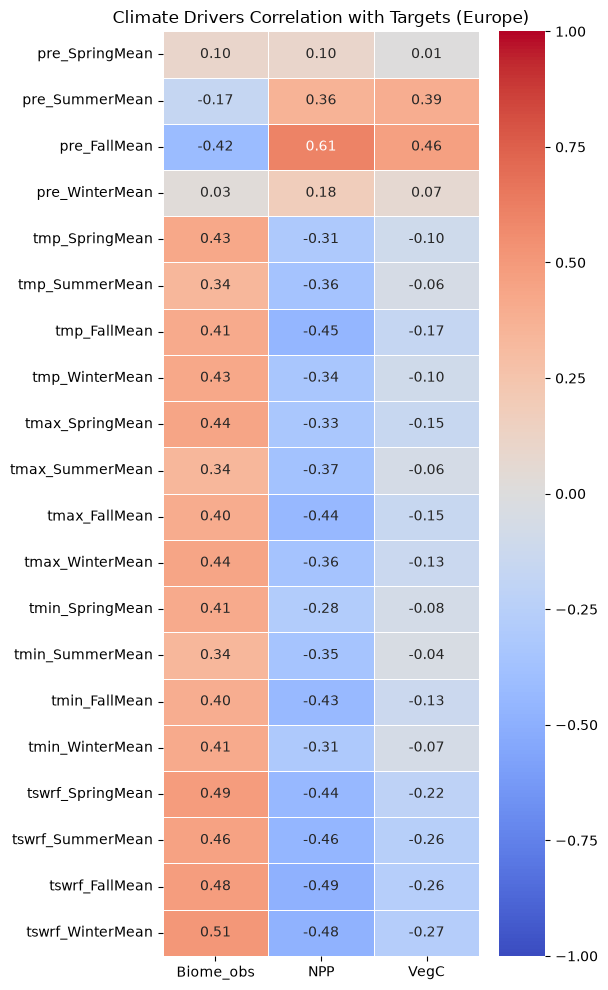

In [17]:

feature_cols = [
    'pre_SpringMean', 'pre_SummerMean', 'pre_FallMean', 'pre_WinterMean',
    'tmp_SpringMean', 'tmp_SummerMean', 'tmp_FallMean', 'tmp_WinterMean',
    'tmax_SpringMean', 'tmax_SummerMean', 'tmax_FallMean', 'tmax_WinterMean',
    'tmin_SpringMean', 'tmin_SummerMean', 'tmin_FallMean', 'tmin_WinterMean',
    'tswrf_SpringMean', 'tswrf_SummerMean', 'tswrf_FallMean', 'tswrf_WinterMean'
]
target_cols = ['Biome_obs', 'NPP', 'VegC']

sub_corr = df_europe[feature_cols + target_cols].corr().loc[feature_cols, target_cols]

plt.figure(figsize=(6, 10))
sns.heatmap(
    sub_corr, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5, 
    vmin=-1, vmax=1
)

plt.title('Climate Drivers Correlation with Targets (Europe)', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:

# Extract absolute correlation values for Biome_obs and sort descending
biome_corr_sorted = sub_corr['Biome_obs'].abs().sort_values(ascending=False)

print("==================================================")
print("  Top 5 Most Influential Climate Drivers for Biome_obs")
print("==================================================")
top5_biome = sub_corr.loc[biome_corr_sorted.index[:5], ['Biome_obs']]
print(top5_biome)
print("\n")

# Extract absolute correlation values for NPP and sort descending
npp_corr_sorted = sub_corr['NPP'].abs().sort_values(ascending=False)

print("==================================================")
print("  Top 5 Most Influential Climate Drivers for NPP")
print("==================================================")
top5_npp = sub_corr.loc[npp_corr_sorted.index[:5], ['NPP']]
print(top5_npp)



# Extract absolute correlation values for VegC and sort descending
vegc_corr_sorted = sub_corr['VegC'].abs().sort_values(ascending=False)

print("==================================================")
print("  Top 5 Most Influential Climate Drivers for VegC")
print("==================================================")
top5_vegc = sub_corr.loc[vegc_corr_sorted.index[:5], ['VegC']]
print(top5_vegc)

  Top 5 Most Influential Climate Drivers for Biome_obs
                  Biome_obs
tswrf_WinterMean   0.512580
tswrf_SpringMean   0.490645
tswrf_FallMean     0.478692
tswrf_SummerMean   0.457003
tmax_SpringMean    0.439683


  Top 5 Most Influential Climate Drivers for NPP
                       NPP
pre_FallMean      0.605879
tswrf_FallMean   -0.486261
tswrf_WinterMean -0.483828
tswrf_SummerMean -0.455950
tmp_FallMean     -0.453733
  Top 5 Most Influential Climate Drivers for VegC
                      VegC
pre_FallMean      0.464443
pre_SummerMean    0.391408
tswrf_WinterMean -0.266073
tswrf_FallMean   -0.262636
tswrf_SummerMean -0.257545


In [19]:
df_europe.head()

,Lon,Lat,pre_SpringMean,pre_SummerMean,pre_FallMean,pre_WinterMean,tmp_SpringMean,tmp_SummerMean,tmp_FallMean,tmp_WinterMean,...,VegC,LitterC,SoilC,Biome_Cmax,Biome_LAI,Biome_obs,GFED-region,ISO3,UN,Ecoregion
12,24.25,51.75,0.98248,1.8373,2.0895,1.3034,270.75,285.99,289.39,276.10,...,7.701,9.439,16.046,5,5,5,11,BLR,112,4
33,25.75,50.75,0.98353,1.9468,2.1311,1.2233,270.59,286.20,289.55,275.97,...,9.077,6.723,15.222,5,5,5,11,UKR,804,4
45,10.25,62.25,1.04720,1.3020,2.3092,1.4383,264.44,276.09,280.66,268.64,...,6.446,18.294,28.623,2,2,2,6,NOR,578,11
50,28.25,64.25,1.11170,1.5451,2.4035,1.6442,262.43,279.57,285.03,269.05,...,9.638,18.268,31.691,2,2,2,6,FIN,246,6
73,19.75,68.75,1.11800,1.1252,1.9308,1.3779,261.56,274.35,280.43,266.17,...,0.142,0.803,14.560,11,11,18,6,NOR,578,11


In [20]:
del df_europe['ISO3']
del df_canada['ISO3']
del df_australia['ISO3']
del df_south_america['ISO3']

In [21]:
file_path = "data/soilmap.dat"
df_soil = pd.read_csv(file_path, sep=r'\s+')


df_europe = df_europe.copy()
df_canada = df_canada.copy()
df_australia = df_australia.copy()
df_south_america = df_south_america.copy()

precision = 4
#europe
df_europe['lon_round'] = df_europe['Lon'].round(precision)
df_europe['lat_round'] = df_europe['Lat'].round(precision)

df_canada['lon_round'] = df_canada['Lon'].round(precision)
df_canada['lat_round'] = df_canada['Lat'].round(precision)

df_australia['lon_round'] = df_australia['Lon'].round(precision)
df_australia['lat_round'] = df_australia['Lat'].round(precision)

df_south_america['lon_round'] = df_south_america['Lon'].round(precision)
df_south_america['lat_round'] = df_south_america['Lat'].round(precision)


df_soil['lon_round'] = df_soil['lon'].round(precision)
df_soil['lat_round'] = df_soil['lat'].round(precision)


soil_cols = ['lon_round', 'lat_round', 'clay', 'silt', 'sand', 'orgC', 'pH', 'CN']

soil_cols = [col for col in soil_cols if col in df_soil.columns]


df_europe = pd.merge(
    df_europe,
    df_soil[soil_cols],
    on=['lon_round', 'lat_round'],
    how='left'
)

df_canada = pd.merge(
    df_canada,
    df_soil[soil_cols],
    on=['lon_round', 'lat_round'],
    how='left'
)

df_australia = pd.merge(
    df_australia,
    df_soil[soil_cols],
    on=['lon_round', 'lat_round'],
    how='left'
)

df_south_america = pd.merge(
    df_south_america,
    df_soil[soil_cols],
    on=['lon_round', 'lat_round'],
    how='left'
)


df_europe.drop(columns=['lon_round', 'lat_round'], inplace=True)
df_canada.drop(columns=['lon_round', 'lat_round'], inplace=True)
df_australia.drop(columns=['lon_round', 'lat_round'], inplace=True)
df_south_america.drop(columns=['lon_round', 'lat_round'], inplace=True)





In [22]:
#df_europe.dtypes.to_frame(name='Data_Type')
df_canada.dtypes.to_frame(name='Data_Type')

,Data_Type
Lon,float64
Lat,float64
pre_SpringMean,float64
pre_SummerMean,float64
pre_FallMean,float64
pre_WinterMean,float64
tmp_SpringMean,float64
tmp_SummerMean,float64
tmp_FallMean,float64
tmp_WinterMean,float64


In [23]:
# Section 3 binary classification
forest_codes = [2]

df_europe['is_forest'] = df_europe['Biome_obs'].isin(forest_codes).astype(int)

print("\n ratio of 'is_forest'：")
print(df_europe['is_boreal_ever_forest'].value_counts())


 ratio of 'is_forest'：
is_forest
0    2503
1     648
Name: count, dtype: int64


In [24]:
print(list(df_europe.columns))

['Lon', 'Lat', 'pre_SpringMean', 'pre_SummerMean', 'pre_FallMean', 'pre_WinterMean', 'tmp_SpringMean', 'tmp_SummerMean', 'tmp_FallMean', 'tmp_WinterMean', 'tmax_SpringMean', 'tmax_SummerMean', 'tmax_FallMean', 'tmax_WinterMean', 'tmin_SpringMean', 'tmin_SummerMean', 'tmin_FallMean', 'tmin_WinterMean', 'tswrf_SpringMean', 'tswrf_SummerMean', 'tswrf_FallMean', 'tswrf_WinterMean', 'NPP', 'SoilR', 'MaxBiomeCmax', 'MaxBiomeLAI', 'VegC', 'LitterC', 'SoilC', 'Biome_Cmax', 'Biome_LAI', 'Biome_obs', 'GFED-region', 'UN', 'Ecoregion', 'clay', 'silt', 'sand', 'orgC', 'pH', 'CN', 'is_forest']


In [25]:
df_clean = df_europe.drop(columns=['clay_y', 'silt_y', 'sand_y', 'orgC_y', 'pH_y', 'CN_y'],errors='ignore').copy()
df_clean.rename(columns={
    'clay_x': 'clay', 'silt_x': 'silt', 'sand_x': 'sand',
    'orgC_x': 'orgC', 'pH_x': 'pH', 'CN_x': 'CN'
}, inplace=True)

drop_cols = [
    'is_forest', 
    'Biome_obs',  
    'Biome_Cmax', 
    'Biome_LAI', 
    'GFED-region', 
    'UN', 
    'Ecoregion', 
    'Lon', 'Lat' 
]


X = df_clean.drop(columns=drop_cols)
y = df_clean['is_forest']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)


print(f"Feature list({X.shape[1]} ):")
print(list(X.columns))

print(f"\ntraining set: {X_train.shape[0]}, validation set: {X_val.shape[0]}")
print("\n BE forest ratio in training set:", round(y_train.mean(), 3))
print(" BE forest ratio in validation set:", round(y_val.mean(), 3))

Feature list(33 ):
['pre_SpringMean', 'pre_SummerMean', 'pre_FallMean', 'pre_WinterMean', 'tmp_SpringMean', 'tmp_SummerMean', 'tmp_FallMean', 'tmp_WinterMean', 'tmax_SpringMean', 'tmax_SummerMean', 'tmax_FallMean', 'tmax_WinterMean', 'tmin_SpringMean', 'tmin_SummerMean', 'tmin_FallMean', 'tmin_WinterMean', 'tswrf_SpringMean', 'tswrf_SummerMean', 'tswrf_FallMean', 'tswrf_WinterMean', 'NPP', 'SoilR', 'MaxBiomeCmax', 'MaxBiomeLAI', 'VegC', 'LitterC', 'SoilC', 'clay', 'silt', 'sand', 'orgC', 'pH', 'CN']

training set: 2520, validation set: 631

forest ratio in training set: 0.206
forest ratio in validation set: 0.206


In [26]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_val)


print("accuracy:", accuracy_score(y_val, y_pred))

print("\n classification prediction:")
print(classification_report(y_val, y_pred, target_names=['is not BEforest (0)', 'is BEforest (1)']))

accuracy: 0.9920760697305864

 classification prediction:
                   precision    recall  f1-score   support

is not forest (0)       1.00      0.99      0.99       501
    is forest (1)       0.97      0.99      0.98       130

         accuracy                           0.99       631
        macro avg       0.98      0.99      0.99       631
     weighted avg       0.99      0.99      0.99       631



In [27]:
df_can_test = df_canada.copy()

if 'clay_y' in df_can_test.columns:
    df_can_test = df_can_test.drop(columns=['clay_y', 'silt_y', 'sand_y', 'orgC_y', 'pH_y', 'CN_y'])
df_can_test.rename(columns={'clay_x': 'clay', 'silt_x': 'silt', 'sand_x': 'sand', 'orgC_x': 'orgC', 'pH_x': 'pH', 'CN_x': 'CN'}, inplace=True)

forest_codes = [2]
df_can_test['is_forest'] = df_can_test['Biome_obs'].isin(forest_codes).astype(int)

X_canada = df_can_test[X_train.columns]
y_canada = df_can_test['is_forest']

y_pred_canada = rf_model.predict(X_canada)

from sklearn.metrics import classification_report
print("=" * 50)
print("       Effects of European-trained model on Canada       ")
print("=" * 50)
print(classification_report(y_canada, y_pred_canada, target_names=['is not BEforest (0)', 'is BEforest (1)']))

       Effects of European-trained model on Canada       
                   precision    recall  f1-score   support

is not forest (0)       0.80      0.98      0.88      3608
    is forest (1)       0.97      0.69      0.81      2891

         accuracy                           0.85      6499
        macro avg       0.88      0.84      0.84      6499
     weighted avg       0.87      0.85      0.85      6499



In [28]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("=" * 50)
print("              Top 10 important features             ")
print("=" * 50)
print(importances.head(10).round(4))

top10_features = importances.head(10).index.tolist()

rf_small = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_small.fit(X_train[top10_features], y_train)

y_pred_small = rf_small.predict(X_val[top10_features])
print("\n accuracy with a model trained by top 10 features:", round((y_pred_small == y_val).mean(), 4))

              Top 10 important features             
tmin_SummerMean     0.1818
tmax_SummerMean     0.1245
tmp_SummerMean      0.1226
tmp_FallMean        0.1070
tmin_FallMean       0.1010
tmax_FallMean       0.0395
tswrf_WinterMean    0.0370
tmp_WinterMean      0.0364
LitterC             0.0320
tmin_WinterMean     0.0300
dtype: float64

 accuracy with a model trained by top 10 features: 0.9905


In [33]:
df_aus_test = df_australia.copy()

if 'clay_y' in df_aus_test.columns:
    df_aus_test = df_aus_test.drop(columns=['clay_y', 'silt_y', 'sand_y', 'orgC_y', 'pH_y', 'CN_y'])
df_aus_test.rename(columns={
    'clay_x': 'clay', 'silt_x': 'silt', 'sand_x': 'sand',
    'orgC_x': 'orgC', 'pH_x': 'pH', 'CN_x': 'CN'
}, inplace=True)

forest_codes = [2]
df_aus_test['is_forest'] = df_aus_test['Biome_obs'].isin(forest_codes).astype(int)

X_australia = df_aus_test[X_train.columns]
y_australia = df_aus_test['is_forest']

y_pred_aus = rf_model.predict(X_australia)

print("=" * 50)
print("      Effects of European-trained model on Australia       ")
print("=" * 50)
print(classification_report(y_australia, y_pred_aus, target_names=['isnot BEforest (0)', 'is BEforest (1)'], digits=4))

print("\n True sample value in Australia：")
print(y_australia.value_counts())

      Effects of European-trained model on Australia       
                    precision    recall  f1-score   support

isnot BEforest (0)     1.0000    0.9972    0.9986      2825
   is BEforest (1)     0.1111    1.0000    0.2000         1

          accuracy                         0.9972      2826
         macro avg     0.5556    0.9986    0.5993      2826
      weighted avg     0.9997    0.9972    0.9983      2826


 True sample value in Australia：
is_forest
0    2825
1       1
Name: count, dtype: int64


In [30]:
#Task 4

In [31]:
def clean_dataset(df):
    df_c = df.copy()
    y_cols = [c for c in df_c.columns if c.endswith('_y')]
    if y_cols:
        df_c.drop(columns=y_cols, inplace=True)
    rename_dict = {c: c.replace('_x', '') for c in df_c.columns if c.endswith('_x')}
    if rename_dict:
        df_c.rename(columns=rename_dict, inplace=True)
    return df_c

df_can_clean = clean_dataset(df_canada)
df_eur_clean = clean_dataset(df_europe)

drop_cols = [
    'Biome_obs', 'Biome_Cmax', 'Biome_LAI', 
    'is_forest', 'GFED-region', 'UN', 'Ecoregion', 'Lon', 'Lat'
]

features = [col for col in df_can_clean.columns if col not in drop_cols]

X_train_can = df_can_clean[features]
y_train_can = df_can_clean['Biome_obs']

X_test_eur = df_eur_clean[features]
y_test_eur = df_eur_clean['Biome_obs']

can_biomes = set(y_train_can.unique())
eur_biomes = set(y_test_eur.unique())

missing_in_can = eur_biomes - can_biomes

print(f"✅ Successfully aligned environmental features! Total features: {len(features)}")
print(f"Canada (Training set) samples: {X_train_can.shape[0]}")
print(f"Europe (Testing set) samples: {X_test_eur.shape[0]}\n")

print(f"Biome classes in Canada ({len(can_biomes)} types): {sorted(list(can_biomes))}")
print(f"Biome classes in Europe ({len(eur_biomes)} types): {sorted(list(eur_biomes))}")

if missing_in_can:
    print(f"\n⚠️ Warning: Biome classes present in Europe but missing in Canada: {sorted(list(missing_in_can))}")
    print("The model will yield 0% recall for these missing classes during evaluation.")
else:
    print("\n✅ Canada training set perfectly covers all Biome classes present in Europe.")

✅ Successfully aligned environmental features! Total features: 33
Canada (Training set) samples: 6499
Europe (Testing set) samples: 3151

Biome classes in Canada (12 types): [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]
Biome classes in Europe (12 types): [np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(17), np.int64(18)]

⚠️ Warning: Biome classes present in Europe but missing in Canada: [np.int64(6), np.int64(7)]
The model will yield 0% recall for these missing classes during evaluation.


In [32]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

#Perform 5-fold cross-validation grid search on Canada training data
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("=" * 60)
print("Starting GridSearchCV Hyperparameter Tuning on Canada Dataset...")
print("=" * 60)
grid_search.fit(X_train_can, y_train_can)

print("\nBest Hyperparameters Found:")
print(grid_search.best_params_)
print(f"Best Weighted F1-Score during Cross-Validation: {grid_search.best_score_:.4f}")

# Evaluate the best model on independent Europe test set
best_rf = grid_search.best_estimator_
y_pred_eur = best_rf.predict(X_test_eur)

print("\n" + "=" * 60)
print("Multiclass Classification Report on Independent Europe Test Set:")
print("=" * 60)
print(classification_report(y_test_eur, y_pred_eur, digits=4))

Starting GridSearchCV Hyperparameter Tuning on Canada Dataset...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


C:\Users\12532\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



Best Hyperparameters Found:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
Best Weighted F1-Score during Cross-Validation: 0.9847

Multiclass Classification Report on Independent Europe Test Set:
              precision    recall  f1-score   support

           2     0.8195    0.9738    0.8900       648
           3     0.9111    0.1093    0.1952       375
           5     0.7012    0.9923    0.8217      1549
           6     0.0000    0.0000    0.0000       164
           7     0.0000    0.0000    0.0000        48
          11     0.0000    0.0000    0.0000         6
          12     0.8333    0.0485    0.0917       103
          13     0.0000    0.0000    0.0000         1
          14     1.0000    0.8000    0.8889         5
          15     0.3684    0.1221    0.1834       172
          17     1.0000    1.0000    1.0000        10
          18     0.9545    0.9000    0.9265        70

    accuracy                         0.7337      3151
   mac

C:\Users\12532\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\12532\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\12532\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

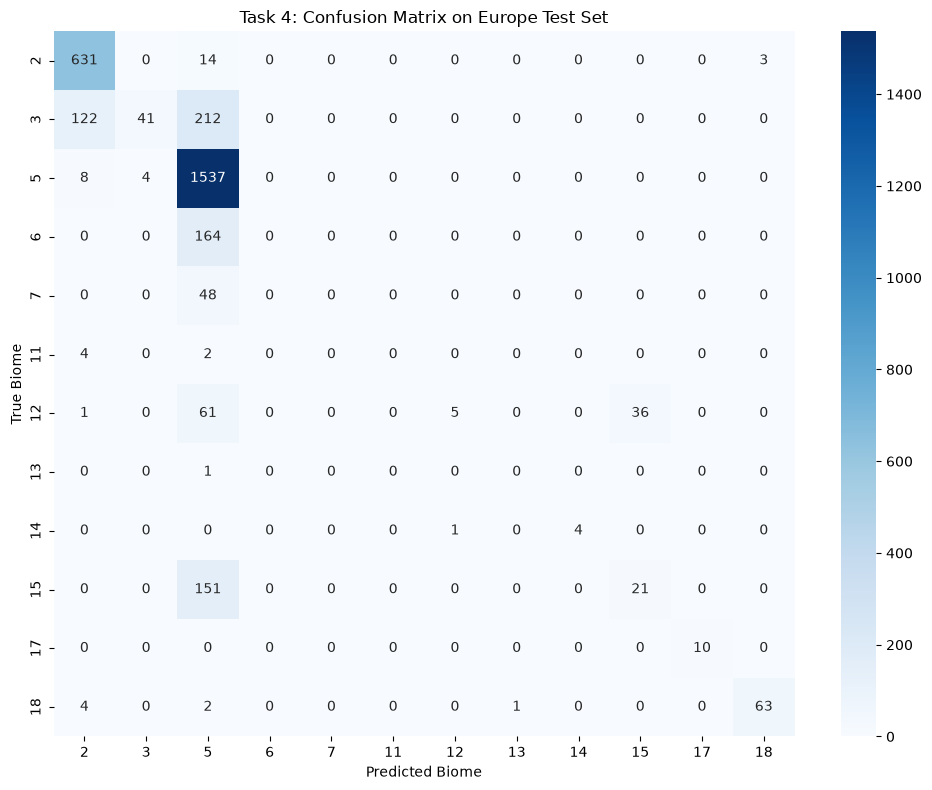

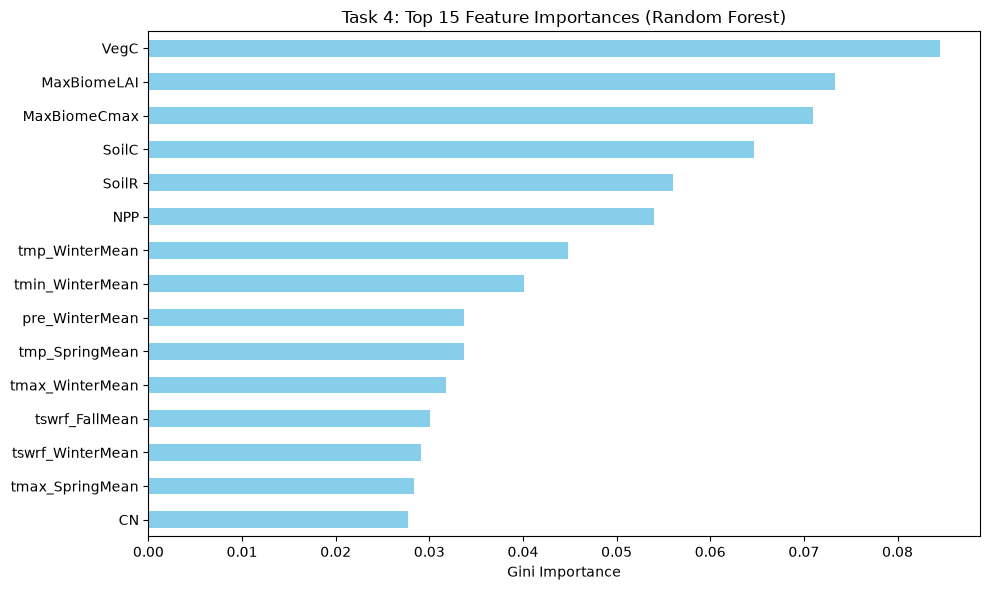

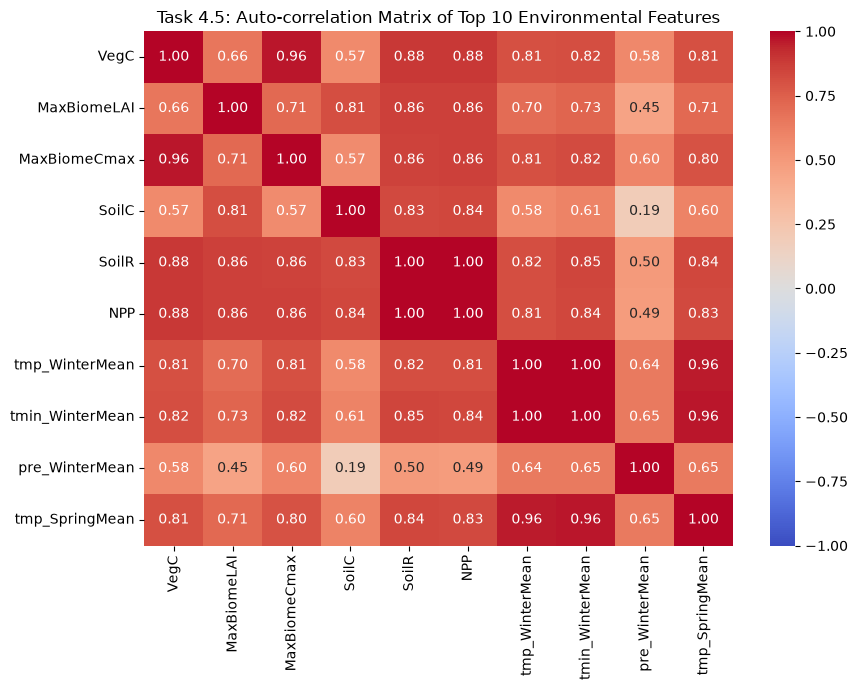


Top 10 Feature Importances List:
VegC               0.0846
MaxBiomeLAI        0.0733
MaxBiomeCmax       0.0709
SoilC              0.0647
SoilR              0.0560
NPP                0.0540
tmp_WinterMean     0.0448
tmin_WinterMean    0.0401
pre_WinterMean     0.0337
tmp_SpringMean     0.0337
dtype: float64


In [34]:
# 1. Plot Confusion Matrix for Europe Test Set
cm = confusion_matrix(y_test_eur, y_pred_eur)
labels = sorted(list(set(y_test_eur.unique()).union(set(np.unique(y_pred_eur)))))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('Task 4: Confusion Matrix on Europe Test Set')
plt.xlabel('Predicted Biome')
plt.ylabel('True Biome')
plt.tight_layout()
plt.show()

# 2. Extract and Plot Top 15 Feature Importances
importances = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()
plt.title('Task 4: Top 15 Feature Importances (Random Forest)')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()

# 3. Section 4.5: Feature Auto-correlation Matrix (Check Collinearity among Top Features)
top_features = importances.head(10).index.tolist()
corr_matrix = X_train_can[top_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Task 4.5: Auto-correlation Matrix of Top 10 Environmental Features')
plt.tight_layout()
plt.show()

print("\nTop 10 Feature Importances List:")
print(importances.head(10).round(4))